In [1]:
import torch
from torch.utils.data import DataLoader, random_split, TensorDataset
from d2l import torch as d2l
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import math
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MTFraEng(d2l.DataModule):
    def _download(self):
        d2l.extract(d2l.download(
            d2l.DATA_URL + 'fra-eng.zip', self.root,
            '94646ad1522d915e7b0f9296181140edcf86a4f5'))
        with open(self.root + '/fra-eng/fra.txt', encoding='utf-8') as f:
            return f.read()

raw_text = MTFraEng()._download()


def tokenize_simple(text):
    return text.lower().strip().split()

def custom_preprocess(text):
    lines = text.strip().split('\n')
    pairs = [line.split('\t') for line in lines if '\t' in line]
    src = [tokenize_simple(s) for s, _ in pairs]
    tgt = [tokenize_simple(t) for _, t in pairs]
    return src, tgt

src_sentences, tgt_sentences = custom_preprocess(raw_text)
src_sentences = src_sentences[:3000]
tgt_sentences = tgt_sentences[:3000]

reserved_tokens = ['<pad>', '<bos>', '<eos>', '<unk>']
src_vocab = d2l.Vocab(src_sentences, min_freq=1, reserved_tokens=reserved_tokens)
tgt_vocab = d2l.Vocab(tgt_sentences, min_freq=1, reserved_tokens=reserved_tokens)

pad_idx = tgt_vocab['<pad>']
bos_idx = tgt_vocab['<bos>']
eos_idx = tgt_vocab['<eos>']

def build_tensor(lines, vocab, num_steps, bos=False, eos=False):
    out = []
    for line in lines:
        tokens = ([vocab['<bos>']] if bos else []) + \
                 [vocab[token] if token in vocab.token_to_idx else vocab['<unk>'] for token in line] + \
                 ([vocab['<eos>']] if eos else [])
        if len(tokens) > num_steps:
            tokens = tokens[:num_steps]
        else:
            tokens += [vocab['<pad>']] * (num_steps - len(tokens))
        out.append(torch.tensor(tokens))
    return torch.stack(out)

num_steps = 20
src_tensor = build_tensor(src_sentences, src_vocab, num_steps, eos=True)
tgt_tensor = build_tensor(tgt_sentences, tgt_vocab, num_steps, bos=True, eos=True)

full_dataset = TensorDataset(src_tensor, tgt_tensor)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

test_pairs = list(zip(
    [" ".join(s) for s in src_sentences[:10]],
    [" ".join(t) for t in tgt_sentences[:10]]
))

def tokenizer_src(sentence):
    tokens = sentence.lower().strip().split()
    token_ids = [src_vocab[token] if token in src_vocab.token_to_idx else src_vocab['<unk>'] for token in tokens]
    token_ids.append(src_vocab['<eos>'])
    return torch.tensor(token_ids, dtype=torch.long, device=device).unsqueeze(0) 





In [2]:
class FeedForwardBlock(nn.Module):
    def __init__(self, ffn_num_hiddens, ffn_num_outputs):
        super().__init__()
        self.dense1 = nn.Linear(ffn_num_outputs, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

class AddNorm(nn.Module):
    def __init__(self, norm_shape, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(norm_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

class TransformerEncoderBlock(nn.Module):
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout, use_self_attention=True):
        super().__init__()
        self.use_self_attention = use_self_attention
        if self.use_self_attention:
            self.attention = d2l.MultiHeadAttention(num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.ffn = FeedForwardBlock(ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(num_hiddens, dropout)

    def forward(self, X, valid_lens):
        if self.use_self_attention:
            X2 = self.attention(X, X, X, valid_lens)
        else:
            X2 = X
        X = self.addnorm1(X, X2)
        return self.addnorm2(X, self.ffn(X))


class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads, num_layers,
                 dropout, use_pe=True, use_self_attention=True):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.use_pe = use_pe
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        if self.use_pe:
            self.pe = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential(*[
            TransformerEncoderBlock(num_hiddens, ffn_num_hiddens, num_heads, dropout,
                                    use_self_attention=use_self_attention)
            for _ in range(num_layers)
        ])

    def forward(self, X, valid_lens):
        X = self.embedding(X) * math.sqrt(self.num_hiddens)
        if self.use_pe:
            X = self.pe(X)
        for blk in self.blks:
            X = blk(X, valid_lens)
        return X


class PositionalEncoding(nn.Module):
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(-1, 1) / \
            torch.pow(10000, torch.arange(0, num_hiddens, 2) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)


class TransformerDecoderBlock(nn.Module):
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout, i):
        super().__init__()
        self.i = i
        self.attn1 = d2l.MultiHeadAttention(num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.attn2 = d2l.MultiHeadAttention(num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(num_hiddens, dropout)
        self.ffn = FeedForwardBlock(ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(num_hiddens, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        key_values = state[2][self.i]
        if key_values is None:
            key_values = X
        else:
            key_values = torch.cat((key_values, X), dim=1)
        state[2][self.i] = key_values
        batch_size, num_steps, _ = X.shape
        if self.training:
            dec_valid_lens = torch.arange(1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None
        X2 = self.attn1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        Z = self.addnorm2(Y, self.attn2(Y, enc_outputs, enc_outputs, enc_valid_lens))
        return self.addnorm3(Z, self.ffn(Z)), state

class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads, num_layers, dropout):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pe = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.ModuleList([
            TransformerDecoderBlock(num_hiddens, ffn_num_hiddens, num_heads, dropout, i)
            for i in range(num_layers)])
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens):
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        X = self.pe(self.embedding(X) * math.sqrt(self.num_hiddens))
        for blk in self.blks:
            X, state = blk(X, state)
        return self.dense(X), state


class TransformerSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        enc_valid_lens = (src != src_vocab['<pad>']).sum(1)
        enc_outputs = self.encoder(src, enc_valid_lens)
        dec_state = self.decoder.init_state(enc_outputs, enc_valid_lens)
        return self.decoder(tgt, dec_state)


In [3]:
def train_transformer(model, train_loader, val_loader, optimizer, criterion, num_epochs):
    train_losses, val_losses = [], []
    for epoch in range(num_epochs):
        model.train()
        total_loss, total_tokens = 0, 0
        for src, tgt in train_loader:
            src, tgt = src.to(device), tgt.to(device)
            optimizer.zero_grad()
            dec_input = tgt[:, :-1]
            dec_target = tgt[:, 1:]
            output, _ = model(src, dec_input)
            loss = criterion(output.reshape(-1, output.shape[-1]), dec_target.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()
            total_loss += loss.item() * dec_target.numel()
            total_tokens += dec_target.numel()

        avg_train_loss = total_loss / total_tokens
        train_losses.append(avg_train_loss)

        print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f} | Perplexity: {np.exp(avg_train_loss):.2f}")

        model.eval()
        val_loss, val_tokens = 0, 0
        with torch.no_grad():
            for src, tgt in val_loader:
                src, tgt = src.to(device), tgt.to(device)
                dec_input = tgt[:, :-1]
                dec_target = tgt[:, 1:]
                output, _ = model(src, dec_input)
                loss = criterion(output.reshape(-1, output.shape[-1]), dec_target.reshape(-1))
                val_loss += loss.item() * dec_target.numel()
                val_tokens += dec_target.numel()

        avg_val_loss = val_loss / val_tokens
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1} - Val Loss: {avg_val_loss:.4f} | Val Perplexity: {np.exp(avg_val_loss):.2f}")

    return train_losses, val_losses

def predict_transformer(model, src_tensor, max_len=20):
    model.eval()
    with torch.no_grad():
        if src_tensor.ndim == 1:
            src_tensor = src_tensor.unsqueeze(0)
            valid_lens = torch.tensor([len(src_tensor[0])], device=device)
        else:
            valid_lens = (src_tensor != src_vocab['<pad>']).sum(1)

        enc_outputs = model.encoder(src_tensor, valid_lens)
        dec_input = torch.tensor([[bos_idx]], device=device)
        state = model.decoder.init_state(enc_outputs, valid_lens)
        outputs = []
        for _ in range(max_len):
            dec_output, state = model.decoder(dec_input, state)
            pred = dec_output[:, -1, :].argmax(dim=-1)
            if pred.item() == eos_idx:
                break
            outputs.append(pred.item())
            dec_input = torch.cat((dec_input, pred.unsqueeze(0)), dim=1)

    return outputs, state

def compute_bleu(pred_indices, tgt_sentence, tgt_vocab):
    pred_tokens = [tgt_vocab.idx_to_token[idx] for idx in pred_indices if idx < len(tgt_vocab)]
    ref_tokens = tgt_sentence.lower().split()
    smoothing = SmoothingFunction().method1
    return sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoothing)


def evaluate_bleu(model, test_pairs, tgt_vocab):
    model.eval()
    total_score = 0
    for src_text, tgt_text in test_pairs:
        src_tensor = tokenizer_src(src_text)
        pred_indices, _ = predict_transformer(model, src_tensor)
        score = compute_bleu(pred_indices, tgt_text, tgt_vocab)
        total_score += score
    return total_score / len(test_pairs)


 Transformer Config 1: 2 heads | PosEncoding: True | SelfAttn: True
Epoch 1 - Train Loss: 4.4367 | Perplexity: 84.50
Epoch 1 - Val Loss: 4.0027 | Val Perplexity: 54.74
Epoch 2 - Train Loss: 3.3361 | Perplexity: 28.11
Epoch 2 - Val Loss: 3.7009 | Val Perplexity: 40.48
Epoch 3 - Train Loss: 2.7405 | Perplexity: 15.49
Epoch 3 - Val Loss: 3.6299 | Val Perplexity: 37.71
Epoch 4 - Train Loss: 2.3155 | Perplexity: 10.13
Epoch 4 - Val Loss: 3.5344 | Val Perplexity: 34.27
Epoch 5 - Train Loss: 1.9646 | Perplexity: 7.13
Epoch 5 - Val Loss: 3.5976 | Val Perplexity: 36.51
Epoch 6 - Train Loss: 1.7147 | Perplexity: 5.56
Epoch 6 - Val Loss: 3.6710 | Val Perplexity: 39.29
Epoch 7 - Train Loss: 1.4900 | Perplexity: 4.44
Epoch 7 - Val Loss: 3.6768 | Val Perplexity: 39.52
Epoch 8 - Train Loss: 1.3382 | Perplexity: 3.81
Epoch 8 - Val Loss: 3.8305 | Val Perplexity: 46.09
Epoch 9 - Train Loss: 1.2189 | Perplexity: 3.38
Epoch 9 - Val Loss: 3.9150 | Val Perplexity: 50.15
Epoch 10 - Train Loss: 1.1415 | Perp

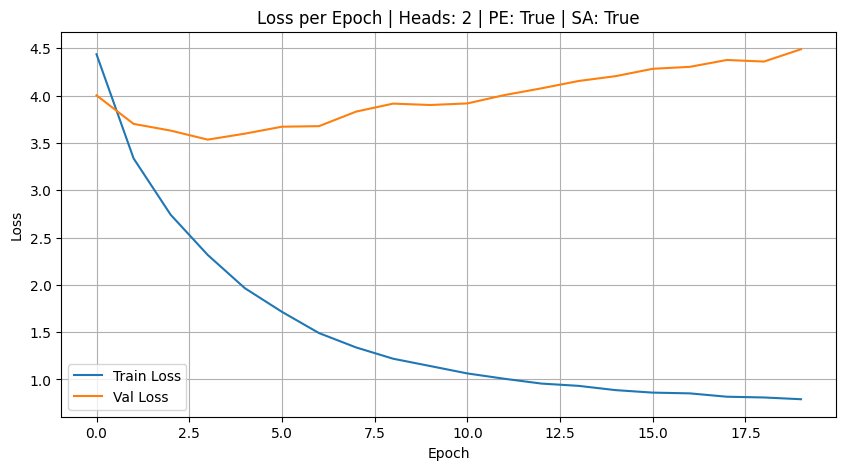


 Transformer Config 2: 2 heads | PosEncoding: False | SelfAttn: True
Epoch 1 - Train Loss: 4.4102 | Perplexity: 82.28
Epoch 1 - Val Loss: 3.9787 | Val Perplexity: 53.45
Epoch 2 - Train Loss: 3.2860 | Perplexity: 26.74
Epoch 2 - Val Loss: 3.6896 | Val Perplexity: 40.03
Epoch 3 - Train Loss: 2.6854 | Perplexity: 14.66
Epoch 3 - Val Loss: 3.6103 | Val Perplexity: 36.98
Epoch 4 - Train Loss: 2.2243 | Perplexity: 9.25
Epoch 4 - Val Loss: 3.5831 | Val Perplexity: 35.99
Epoch 5 - Train Loss: 1.8345 | Perplexity: 6.26
Epoch 5 - Val Loss: 3.5617 | Val Perplexity: 35.22
Epoch 6 - Train Loss: 1.5575 | Perplexity: 4.75
Epoch 6 - Val Loss: 3.6615 | Val Perplexity: 38.92
Epoch 7 - Train Loss: 1.3534 | Perplexity: 3.87
Epoch 7 - Val Loss: 3.7480 | Val Perplexity: 42.44
Epoch 8 - Train Loss: 1.2034 | Perplexity: 3.33
Epoch 8 - Val Loss: 3.8234 | Val Perplexity: 45.76
Epoch 9 - Train Loss: 1.0894 | Perplexity: 2.97
Epoch 9 - Val Loss: 3.8426 | Val Perplexity: 46.65
Epoch 10 - Train Loss: 1.0282 | Perp

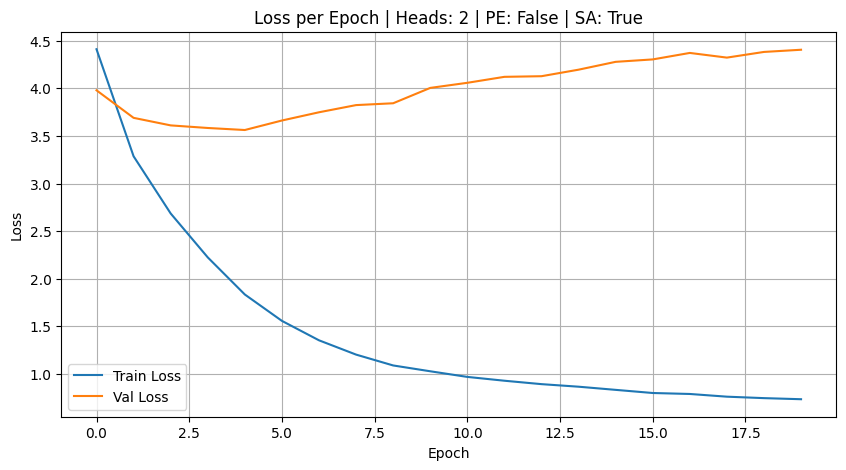


 Transformer Config 3: 2 heads | PosEncoding: True | SelfAttn: False
Epoch 1 - Train Loss: 4.4022 | Perplexity: 81.63
Epoch 1 - Val Loss: 3.8927 | Val Perplexity: 49.04
Epoch 2 - Train Loss: 3.2485 | Perplexity: 25.75
Epoch 2 - Val Loss: 3.5985 | Val Perplexity: 36.54
Epoch 3 - Train Loss: 2.6322 | Perplexity: 13.90
Epoch 3 - Val Loss: 3.5336 | Val Perplexity: 34.25
Epoch 4 - Train Loss: 2.1636 | Perplexity: 8.70
Epoch 4 - Val Loss: 3.5370 | Val Perplexity: 34.37
Epoch 5 - Train Loss: 1.8090 | Perplexity: 6.10
Epoch 5 - Val Loss: 3.6088 | Val Perplexity: 36.92
Epoch 6 - Train Loss: 1.5351 | Perplexity: 4.64
Epoch 6 - Val Loss: 3.6074 | Val Perplexity: 36.87
Epoch 7 - Train Loss: 1.3568 | Perplexity: 3.88
Epoch 7 - Val Loss: 3.6275 | Val Perplexity: 37.62
Epoch 8 - Train Loss: 1.2086 | Perplexity: 3.35
Epoch 8 - Val Loss: 3.7837 | Val Perplexity: 43.98
Epoch 9 - Train Loss: 1.0920 | Perplexity: 2.98
Epoch 9 - Val Loss: 3.9050 | Val Perplexity: 49.65
Epoch 10 - Train Loss: 1.0395 | Perp

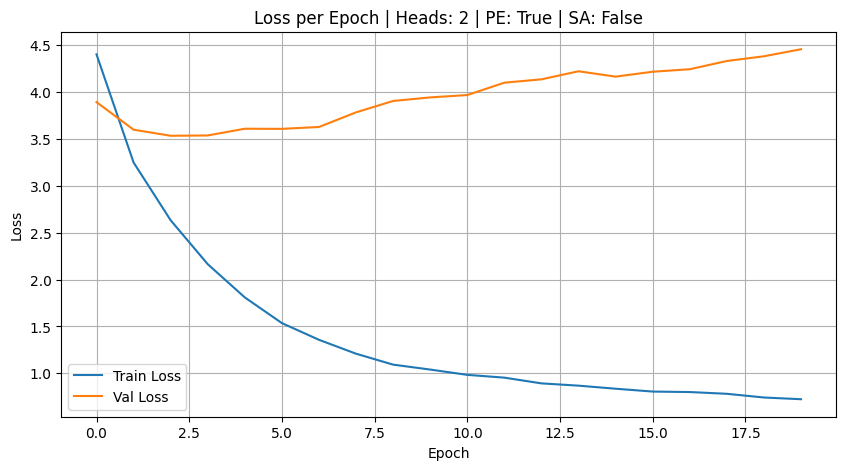

In [4]:
base_hyperparams = {
    "emb_dim": 128,
    "hid_dim": 256,
    "n_layers": 1,
    "dropout": 0.1,
    "lr": 0.001,
    "num_epochs": 20,
    "batch_size": 4
}

ablation_configs = [
    (2, True, True),
    (2, False, True), #no posEncoding
    (2, True, False), #no self attn
]

results = []

for i, (num_heads, use_pe, use_self_attention) in enumerate(ablation_configs):
    print(f"\n Transformer Config {i+1}: {num_heads} heads | PosEncoding: {use_pe} | SelfAttn: {use_self_attention}")

    encoder = TransformerEncoder(
                len(src_vocab), base_hyperparams["emb_dim"], 
                base_hyperparams["hid_dim"],
                num_heads=num_heads, 
                num_layers=base_hyperparams["n_layers"],
                dropout=base_hyperparams["dropout"],
                use_pe=use_pe, use_self_attention=use_self_attention
    )

    decoder = TransformerDecoder(
                len(tgt_vocab), base_hyperparams["emb_dim"], 
                base_hyperparams["hid_dim"],
                num_heads=num_heads, 
                num_layers=base_hyperparams["n_layers"],
                dropout=base_hyperparams["dropout"]
    )

    model = TransformerSeq2Seq(encoder, decoder).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=base_hyperparams["lr"])
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
    train_losses, val_losses = train_transformer(model, train_loader, val_loader, optimizer, criterion, num_epochs=base_hyperparams["num_epochs"])
    bleu_score = evaluate_bleu(model, test_pairs, tgt_vocab)
    print(f"\n BLEU Score: {bleu_score:.4f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title(f"Loss per Epoch | Heads: {num_heads} | PE: {use_pe} | SA: {use_self_attention}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    results.append({
        "num_heads": num_heads,
        "use_pe": use_pe,
        "use_self_attention": use_self_attention,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "bleu": bleu_score
    })